In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

df = pd.read_csv("diabetes.csv")

zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_features:
    df[col] = df[col].replace(0, np.nan)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)

scaler = RobustScaler()
X_train_processed = scaler.fit_transform(X_train_imputed)
X_test_processed = scaler.transform(X_test_imputed)

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)


In [ ]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_processed, label=y_train)
dtest = xgb.DMatrix(X_test_processed, label=y_test)

params = {
    "max_depth": 3,
    "min_child_weight": 5,
    "gamma": 0.2,
    "reg_alpha": 1,
    "reg_lambda": 2,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "seed": 42
}

evals = [(dtrain, "train"), (dtest, "eval")]

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=True
)


[0]	train-logloss:0.60311	eval-logloss:0.61556
[1]	train-logloss:0.55161	eval-logloss:0.57812
[2]	train-logloss:0.51466	eval-logloss:0.55240
[3]	train-logloss:0.49272	eval-logloss:0.53576
[4]	train-logloss:0.47150	eval-logloss:0.52929
[5]	train-logloss:0.45601	eval-logloss:0.52024
[6]	train-logloss:0.44507	eval-logloss:0.51941
[7]	train-logloss:0.43340	eval-logloss:0.51577
[8]	train-logloss:0.42461	eval-logloss:0.50770
[9]	train-logloss:0.41622	eval-logloss:0.50806
[10]	train-logloss:0.40693	eval-logloss:0.51044
[11]	train-logloss:0.40099	eval-logloss:0.50467
[12]	train-logloss:0.39696	eval-logloss:0.51135
[13]	train-logloss:0.39343	eval-logloss:0.51271
[14]	train-logloss:0.39095	eval-logloss:0.51386
[15]	train-logloss:0.38748	eval-logloss:0.51342
[16]	train-logloss:0.38469	eval-logloss:0.51105
[17]	train-logloss:0.38163	eval-logloss:0.51257
[18]	train-logloss:0.37651	eval-logloss:0.51327
[19]	train-logloss:0.37041	eval-logloss:0.51074
[20]	train-logloss:0.36621	eval-logloss:0.51319


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1       0.60      0.78      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



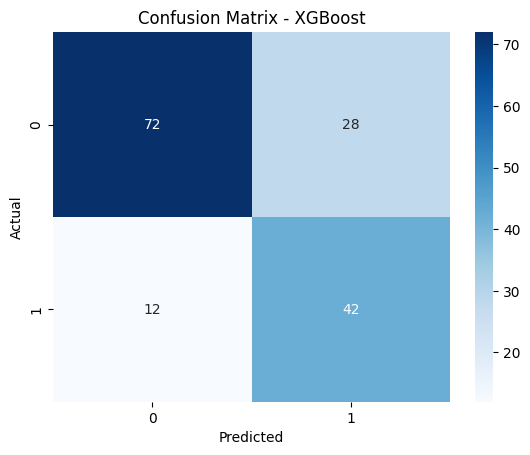

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = xgb_model.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class XGBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, xgb_model, imputer=None, scaler=None):
        self.xgb_model = xgb_model
        self.imputer = imputer
        self.scaler = scaler

    def fit(self, X, y=None):
        return self  

    def predict(self, X):
        X_proc = X
        if self.imputer:
            X_proc = self.imputer.transform(X_proc)
        if self.scaler:
            X_proc = self.scaler.transform(X_proc)
        dmatrix = xgb.DMatrix(X_proc)
        return (self.xgb_model.predict(dmatrix) > 0.5).astype(int)

    def predict_proba(self, X):
        X_proc = X
        if self.imputer:
            X_proc = self.imputer.transform(X_proc)
        if self.scaler:
            X_proc = self.scaler.transform(X_proc)
        dmatrix = xgb.DMatrix(X_proc)
        probs = self.xgb_model.predict(dmatrix)
        return np.vstack([1 - probs, probs]).T

from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("imputer", imputer),
    ("scaler", scaler),
    ("model", XGBWrapper(xgb_model=xgb_model))
])


In [18]:
import joblib

joblib.dump(pipeline, "best_pipeline.pkl")
print("Pipeline saved as 'best_pipeline.pkl'")


Pipeline saved as 'best_pipeline.pkl'
